# **Import**

In [ ]:
# Install required packages
%pip install -q datasets
%pip install -q transformers
%pip install -q sentence-transformers
%pip install -q nltk
%pip install -q google-generativeai
%pip install -q rouge-score bert-score
%pip install seaborn


import os
import sys
from datasets import load_dataset
import json
from transformers import pipeline, set_seed
import random
import torch
from huggingface_hub import login
import getpass
import gc

import string
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.translate import meteor_score
from rouge_score import rouge_scorer
from bert_score import BERTScorer

import pandas as pd
from IPython.display import display

import google.generativeai as genai
import time

from sklearn.metrics import cohen_kappa_score
import matplotlib.pyplot as plt
import seaborn as sns

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


...


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# **Seed to ensure reproducibility**

In [ ]:
def set_seeds(seed=42):

    random.seed(seed)
    # In caso dovessimo usare Numpy
    # np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

    # Seed on transformers library
    set_seed(seed)


set_seeds(seed=42)

# **Hugging Face Login**

In [ ]:
kaggle = False

# Insert the hugging face token
if 'KAGGLE_KERNEL_RUN_TYPE' in os.environ:
    kaggle = True
    try:
        from kaggle_secrets import UserSecretsClient
        user_secrets = UserSecretsClient()
        hf_token = user_secrets.get_secret("HF_TOKEN")

        login(token=hf_token)
        print("✅ You have been automatically logged in to Hugging Face!")

    except Exception as e:
        print("❌ Error Kaggle Secrets: Token not found.")
else:
    print("Please enter your Hugging Face Access Token: (You must have access to Llama 3.2):")
    hf_token = getpass.getpass()
    login(token=hf_token)

Please enter your Hugging Face Access Token: (You must have access to Llama 3.2):


# **Environment Setup**

In [ ]:
colab = False

# Automatic Environment Detection
if 'google.colab' in sys.modules:
    print("🌐 Environment detected: Google Colab")
    colab = True

    # Automatically mount Google Drive
    from google.colab import drive
    drive.mount('/content/drive')

    BASE_DIR = '/content/drive/MyDrive/MNLP_2026_HW2_2278125_2283937/'

elif kaggle:
    print("🔵 Environment detected: Kaggle")

    BASE_DIR = '/kaggle/working/'

else:
    print("💻 Environment detected: Local Machine")
    BASE_DIR = 'C:/Users/djmat/Desktop/Magistrale - Engineering in CS and AI - Sapienza/Multilingual_Natural_Language_Processing/MNLP_Project_2026'

# Defining paths for subdirectories
if kaggle:
    JSON_DIR = '/kaggle/input/datasets/nicolromanelli/json-kaggle'
else:
    JSON_DIR = os.path.join(BASE_DIR, 'JSON')

PLOTS_DIR = os.path.join(BASE_DIR, 'plots')
OUTPUTS_DIR = os.path.join(BASE_DIR, 'outputs')
NO_REQUESTED_OUTPUTS_DIR = os.path.join(BASE_DIR, 'no_requested_outputs')

# Creating directories if they don't exist
os.makedirs(JSON_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(OUTPUTS_DIR, exist_ok=True)
os.makedirs(NO_REQUESTED_OUTPUTS_DIR, exist_ok=True)

print(f"📁 Base Directory set to: {BASE_DIR}")

# Set up hardware acceleration (GPU if available, else CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Device selected: {device}")

💻 Environment detected: Local Machine
📁 Base Directory set to: C:/Users/djmat/Desktop/Magistrale - Engineering in CS and AI - Sapienza/Multilingual_Natural_Language_Processing/MNLP_Project_2026
🚀 Device selected: cuda


# **GPU Usage Debugging Function**

In [ ]:
def gpu_status(label=""):
    allocated = torch.cuda.memory_allocated(0) / 1024**3
    reserved  = torch.cuda.memory_reserved(0)  / 1024**3
    total     = torch.cuda.get_device_properties(0).total_memory / 1024**3
    free      = total - reserved
    print(f"[GPU {label}]")
    print(f"  Allocated:  {allocated:.2f} GB")
    print(f"  Reserved: {reserved:.2f} GB")
    print(f"  Free:    {free:.2f} GB")
    print(f"  Total:    {total:.2f} GB")

# **Dataset Loading and Exploration**

In [ ]:
ds = load_dataset(
    "sapienzanlp-course-materials/hw-mnlp-2026"
)

# Sanity check
for split in ds.keys():
    print(f"Split: {split:6} | Features: {ds[split].column_names}")

# Unpack splits into dedicated variables for easier access
train = ds['train']
test = ds['test']
blind = ds['blind']

Split: test   | Features: ['wikipedia_title', 'wikidata_id', 'query', 'query_id', 'candidate_chunks', 'n_candidates', 'answer', 'answer_pos', 'short_answer']
Split: blind  | Features: ['wikipedia_title', 'wikidata_id', 'query', 'query_id', 'candidate_chunks', 'n_candidates', 'answer', 'answer_pos', 'short_answer']
Split: train  | Features: ['wikipedia_title', 'wikidata_id', 'query', 'query_id', 'candidate_chunks', 'n_candidates', 'answer', 'answer_pos', 'short_answer']


# **Rankings Loading**

In [ ]:
# Rankings file name definition
rankings_test_filename = 'hit_k_1-test-distilbert-triplet-cosine_(reranking).jsonl'
rankings_blind_filename = 'hit_k_1-blind-distilbert-triplet-cosine_(reranking).jsonl'

# Complete path creation
rankings_test_path = os.path.join(JSON_DIR, rankings_test_filename)
rankings_blind_path = os.path.join(JSON_DIR, rankings_blind_filename)

retrieved_results_test = []
retrieved_results_blind = []

# Test set Rankings loading
try:
    with open(rankings_test_path, 'r', encoding='utf-8') as f:
        for line in f:
            retrieved_results_test.append(json.loads(line.strip()))

    print(f"✅ Test Set rankings loaded with success!")
    print(f"   📍 File: {rankings_test_path}")

except FileNotFoundError:
    print(f"❌ ERROR: TEST SET rankings does not found:\n{rankings_test_path}\n")


# Blind set Rankings loading
try:
    with open(rankings_blind_path, 'r', encoding='utf-8') as f:
        for line in f:
            retrieved_results_blind.append(json.loads(line.strip()))

    print(f"✅ Blind Set rankings loaded with success!")
    print(f"   📍 File: {rankings_blind_path}")

except FileNotFoundError:
    print(f"❌ ERROR: BLIND SET rankings does not found:\n{rankings_blind_path}")

# Unique Dictionary creation {'query_id1': [rankings], 'query_id2': [rankings], ...}
rankings_test = {}
for item in retrieved_results_test:
    rankings_test.update(item)

rankings_blind = {}
for item in retrieved_results_blind:
    rankings_blind.update(item)

✅ Test Set rankings loaded with success!
   📍 File: C:/Users/djmat/Desktop/Magistrale - Engineering in CS and AI - Sapienza/Multilingual_Natural_Language_Processing/MNLP_Project_2026\JSON\hit_k_1-test-distilbert-triplet-cosine_(reranking).jsonl
✅ Blind Set rankings loaded with success!
   📍 File: C:/Users/djmat/Desktop/Magistrale - Engineering in CS and AI - Sapienza/Multilingual_Natural_Language_Processing/MNLP_Project_2026\JSON\hit_k_1-blind-distilbert-triplet-cosine_(reranking).jsonl


# **Small LMs Implementation**

In [ ]:
# Function to generate prompts in RAG and Oracle settings for both test and blind sets
def prompts_generation(dataset, rankings, k, oracle=False, prompt_strategy="default"):

        all_prompts = []
        all_retrieved_chunks = []

        queries = dataset['query']
        query_ids = dataset['query_id']
        candidate_chunks = dataset['candidate_chunks']

        blind = all(pos == 100 for pos in dataset['answer_pos'])

        # Mapping query_ids to their corresponding answer positions (only for non-blind datasets)
        if not blind:
            mapped_answers = dict(zip(query_ids, dataset['answer_pos']))
        else:
            mapped_answers = {}
            if oracle:
                print("⚠️ Note: Blind Dataset detected (all values are 100). Oracle mode will be ignored to avoid errors.")

        # Generating prompts for each query
        for q_id, q_text, candidates in zip(query_ids, queries, candidate_chunks):

            # Retrieving the top-k chunk ids for the current query
            best_chunk_positions = rankings.get(q_id, [])[:k]


            if oracle and not blind and q_id in mapped_answers:
                answer_pos = mapped_answers[q_id]

                if answer_pos in best_chunk_positions:
                    # Correct chunk is in top k
                    best_chunk_positions.remove(answer_pos)
                    best_chunk_positions.insert(0, answer_pos)
                else:
                    # Correct chunk is not in top k
                    best_chunk_positions = best_chunk_positions[:-1]
                    best_chunk_positions.insert(0, answer_pos)


            context_block = ""

            # Building the context block with the retrieved chunks
            for i, c_position in enumerate(best_chunk_positions, 1):
                chunk_text = candidates[c_position]
                context_block += f"{i}. {chunk_text}\n"

            if prompt_strategy == "personalized":
                full_prompt = (
                f"You are a precise Question Answering system. Your task is to answer the Question based ONLY on the provided Chunks.\n"
                f"Instructions:\n"
                f"1. Provide the exact short answer to the question.\n"
                f"2. DO NOT provide multiple options.\n"
                f"3. DO NOT repeat the question in your answer.\n"
                f"4. DO NOT use any information outside the provided Chunks.\n"
                f"5. Write the answer only once.\n"
                f"6. DO NOT add any additional information, explanation, or reasoning.\n"
                f"7. Follow the format of the examples:\n\n"

                f"Example 1:\n"
                f"Chunks:\n"
                f"1. France is a country in Western Europe with Paris as its capital city.\n"
                f"2. Europe comprises several nations including France and Germany.\n"
                f"3. Paris is widely known for the Eiffel Tower and its world-class museums.\n"
                f"Reply to this question:\n"
                f"What is the capital of France?\n"
                f"Answer: Paris\n\n"

                f"Example 2:\n"
                f"Chunks:\n"
                f"1. World War II began on September 1, 1939, following the invasion of Poland.\n"
                f"2. The global conflict officially came to an end in 1945.\n"
                f"3. In 1939, several European powers entered the war.\n"
                f"Reply to this question:\n"
                f"In what year did World War II begin?\n"
                f"Answer: 1939\n\n"

                f"Now solve this task:\n"
                f"Chunks:\n"
                f"{context_block}\n"
                f"Reply to this question:\n"
                f"{q_text}?\n"
                f"Answer:"
                )
            else:
                # Writing the prompt with the retrieved context and the query
                full_prompt = (
                f"Given the following information:\n"
                f"{context_block}"
                f"Reply to this question:\n"
                f"{q_text}?"
                )

            all_prompts.append(full_prompt)
            all_retrieved_chunks.append(best_chunk_positions)

        return all_prompts, all_retrieved_chunks

# Function to generate answers for a given dataset and generator
def answers(dataset, generator, settings='Baseline', k=3, prompt_strategy="default"):

    answers = {}

    split = str(dataset.split).capitalize()

    # We get all the queries to work with batches
    queries = list(dataset['query'])
    query_ids = list(dataset['query_id'])

    # Depending on the settings, we either use the raw queries (Baseline) or generate prompts with retrieved context (RAG and Oracle)
    if settings == 'Baseline':
        prompts = queries
        retrieved_chunks = [[] for _ in range(len(queries))]
    elif settings in ['RAG', 'Oracle']:
        prompts, retrieved_chunks = prompts_generation(dataset, rankings_test if split=='Test' else rankings_blind, k=k, oracle=(settings=='Oracle'), prompt_strategy=prompt_strategy)
    else:
        raise ValueError(f"Invalid settings: {settings}. Choose from 'Baseline', 'RAG', or 'Oracle'.")


    # Batch generation of answers using the provided generator pipeline
    print(f"🔍 Starting generation for {len(queries)} queries in {split} set with {settings} setting...")

    # Set the batch size dynamically: 8 on Colab, 16 locally
    current_batch_size = 8 if colab else 16

    outputs = generator(
        prompts,
        batch_size=current_batch_size,
        max_new_tokens=50,
        truncation=True,
        return_full_text=False,
        do_sample=False,
        generation_config=None,
        pad_token_id=generator.tokenizer.eos_token_id
    )
    print(f"✅ Generation completed for {len(queries)} queries in {split} set with {settings} setting.")

    # We iterate over the generated outputs and store them in the answers dictionary
    for q_id, out, prompt, chunks in zip(query_ids, outputs, prompts, retrieved_chunks):

        generated_answer = out[0]['generated_text'].strip()

        answers[q_id] = {
            "query_id": q_id,
            "retrieved_chunks": chunks,
            "augmented_prompt": prompt if settings in ["RAG", "Oracle"] else None,
            "generated_answer": generated_answer
        }

    return answers

## **Llama-3.2-3B-Instruct**

In [ ]:
llama_id = "meta-llama/Llama-3.2-3B-Instruct"
llama = pipeline(
    "text-generation",
    model=llama_id,
    dtype=torch.bfloat16,
    device_map="auto",
    token = True
)

llama.tokenizer.pad_token = llama.tokenizer.eos_token
llama.tokenizer.padding_side = 'left'
llama.tokenizer.model_max_length = 512
llama.generation_config.max_length = None

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

### **Baseline**

In [ ]:
Llama_baseline_test_answers = answers(test, generator=llama)
print("✅ Llama Baseline Test Answers Generation Completed!")
Llama_baseline_blind_answers = answers(blind, generator=llama)
print("✅ Llama Baseline Blind Answers Generation Completed!")

[transformers] Passing `generation_config` together with generation-related arguments=({'temperature', 'max_new_tokens', 'top_p', 'pad_token_id', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


🔍 Starting generation for 2000 queries in Test set with Baseline setting...


KeyboardInterrupt: 

### **RAG**

In [ ]:
# Default
Llama_RAG_test_answers = answers(test, generator=llama, settings='RAG', k=3)
print("✅ Llama RAG Test Answers Generation Completed!")
Llama_RAG_blind_answers = answers(blind, generator=llama, settings='RAG', k=3)
print("✅ Llama RAG Blind Answers Generation Completed!")

🔍 Starting generation for 2000 queries in Test set with RAG setting...
✅ Generation completed for 2000 queries in Test set with RAG setting.
✅ Llama RAG Test Answers Generation Completed!
🔍 Starting generation for 1322 queries in Blind set with RAG setting...
✅ Generation completed for 1322 queries in Blind set with RAG setting.
✅ Llama RAG Blind Answers Generation Completed!


In [ ]:
# Personalized
Llama_RAG_test_answers_personalized = answers(test, generator=llama, settings='RAG', k=3, prompt_strategy="personalized")
print("✅ Llama RAG Test Answers with Personalized Prompts Generation Completed!")
Llama_RAG_blind_answers_personalized = answers(blind, generator=llama, settings='RAG', k=3, prompt_strategy="personalized")
print("✅ Llama RAG Blind Answers with Personalized Prompts Generation Completed!")

[transformers] The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


🔍 Starting generation for 2000 queries in Test set with RAG setting...
✅ Generation completed for 2000 queries in Test set with RAG setting.
✅ Llama RAG Test Answers with Personalized Prompts Generation Completed!
🔍 Starting generation for 1322 queries in Blind set with RAG setting...
✅ Generation completed for 1322 queries in Blind set with RAG setting.
✅ Llama RAG Blind Answers with Personalized Prompts Generation Completed!


### **Oracle**

In [ ]:
# Default
Llama_Oracle_test_answers = answers(test, generator=llama, settings='Oracle', k=3)
print("✅ Llama Oracle Test Answers Generation Completed!")
Llama_Oracle_blind_answers = answers(blind, generator=llama, settings='Oracle', k=3)
print("✅ Llama Oracle Blind Answers Generation Completed!")

🔍 Starting generation for 2000 queries in Test set with Oracle setting...
✅ Generation completed for 2000 queries in Test set with Oracle setting.
✅ Llama Oracle Test Answers Generation Completed!
⚠️ Note: Blind Dataset detected (all values are 100). Oracle mode will be ignored to avoid errors.
🔍 Starting generation for 1322 queries in Blind set with Oracle setting...
✅ Generation completed for 1322 queries in Blind set with Oracle setting.
✅ Llama Oracle Blind Answers Generation Completed!


In [ ]:
# Personalized
Llama_Oracle_test_answers_personalized = answers(test, generator=llama, settings='Oracle', k=3, prompt_strategy="personalized")
print("✅ Llama Oracle Test Answers with Personalized Prompts Generation Completed!")
Llama_Oracle_blind_answers_personalized = answers(blind, generator=llama, settings='Oracle', k=3, prompt_strategy="personalized")
print("✅ Llama Oracle Blind Answers with Personalized Prompts Generation Completed!")

🔍 Starting generation for 2000 queries in Test set with Oracle setting...
✅ Generation completed for 2000 queries in Test set with Oracle setting.
✅ Llama Oracle Test Answers with Personalized Prompts Generation Completed!
⚠️ Note: Blind Dataset detected (all values are 100). Oracle mode will be ignored to avoid errors.
🔍 Starting generation for 1322 queries in Blind set with Oracle setting...
✅ Generation completed for 1322 queries in Blind set with Oracle setting.
✅ Llama Oracle Blind Answers with Personalized Prompts Generation Completed!


## **Qwen3-0.6B**

In [ ]:
# We free up GPU memory by deleting the Llama pipeline and clearing the cache before initializing Qwen
if 'llama' in locals():
    del llama

gc.collect()
torch.cuda.empty_cache()

qwen_id = "Qwen/Qwen3-0.6B"
qwen = pipeline(
    "text-generation",
    model=qwen_id,
    dtype=torch.bfloat16,
    device_map="auto",
    token = True
)

qwen.generation_config.max_length = None

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

### **Baseline**

In [ ]:
Qwen_baseline_test_answers = answers(test, generator=qwen)
print("✅ Qwen Baseline Test Answers Generation Completed!")
Qwen_baseline_blind_answers = answers(blind, generator=qwen)
print("✅ Qwen Baseline Blind Answers Generation Completed!")

[transformers] The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


🔍 Starting generation for 2000 queries in Test set with Baseline setting...
✅ Generation completed for 2000 queries in Test set with Baseline setting.
✅ Qwen Baseline Test Answers Generation Completed!
🔍 Starting generation for 1322 queries in Blind set with Baseline setting...
✅ Generation completed for 1322 queries in Blind set with Baseline setting.
✅ Qwen Baseline Blind Answers Generation Completed!


### **RAG**

In [ ]:
# Default
Qwen_RAG_test_answers = answers(test, generator=qwen, settings='RAG', k=3)
print("✅ Qwen RAG Test Answers Generation Completed!")
Qwen_RAG_blind_answers = answers(blind, generator=qwen, settings='RAG', k=3)
print("✅ Qwen RAG Blind Answers Generation Completed!")

🔍 Starting generation for 2000 queries in Test set with RAG setting...
✅ Generation completed for 2000 queries in Test set with RAG setting.
✅ Qwen RAG Test Answers Generation Completed!
🔍 Starting generation for 1322 queries in Blind set with RAG setting...
✅ Generation completed for 1322 queries in Blind set with RAG setting.
✅ Qwen RAG Blind Answers Generation Completed!


In [ ]:
# Personalized
Qwen_RAG_test_answers_personalized = answers(test, generator=qwen, settings='RAG', k=3, prompt_strategy="personalized")
print("✅ Qwen RAG Test Answers with Personalized Prompts Generation Completed!")
Qwen_RAG_blind_answers_personalized = answers(blind, generator=qwen, settings='RAG', k=3, prompt_strategy="personalized")
print("✅ Qwen RAG Blind Answers with Personalized Prompts Generation Completed!")

[transformers] The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


🔍 Starting generation for 2000 queries in Test set with RAG setting...
✅ Generation completed for 2000 queries in Test set with RAG setting.
✅ Qwen RAG Test Answers with Personalized Prompts Generation Completed!
🔍 Starting generation for 1322 queries in Blind set with RAG setting...
✅ Generation completed for 1322 queries in Blind set with RAG setting.
✅ Qwen RAG Blind Answers with Personalized Prompts Generation Completed!


### **Oracle**

In [ ]:
# Default
Qwen_Oracle_test_answers = answers(test, generator=qwen, settings='Oracle', k=3)
print("✅ Qwen Oracle Test Answers Generation Completed!")
Qwen_Oracle_blind_answers = answers(blind, generator=qwen, settings='Oracle', k=3)
print("✅ Qwen Oracle Blind Answers Generation Completed!")

[transformers] The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


🔍 Starting generation for 2000 queries in Test set with Oracle setting...
✅ Generation completed for 2000 queries in Test set with Oracle setting.
✅ Qwen Oracle Test Answers Generation Completed!
⚠️ Note: Blind Dataset detected (all values are 100). Oracle mode will be ignored to avoid errors.
🔍 Starting generation for 1322 queries in Blind set with Oracle setting...
✅ Generation completed for 1322 queries in Blind set with Oracle setting.
✅ Qwen Oracle Blind Answers Generation Completed!


In [ ]:
# Personalized
Qwen_Oracle_test_answers_personalized = answers(test, generator=qwen, settings='Oracle', k=3, prompt_strategy="personalized")
print("✅ Qwen Oracle Test Answers with Personalized Prompts Generation Completed!")
Qwen_Oracle_blind_answers_personalized = answers(blind, generator=qwen, settings='Oracle', k=3, prompt_strategy="personalized")
print("✅ Qwen Oracle Blind Answers with Personalized Prompts Generation Completed!")

🔍 Starting generation for 2000 queries in Test set with Oracle setting...
✅ Generation completed for 2000 queries in Test set with Oracle setting.
✅ Qwen Oracle Test Answers with Personalized Prompts Generation Completed!
⚠️ Note: Blind Dataset detected (all values are 100). Oracle mode will be ignored to avoid errors.
🔍 Starting generation for 1322 queries in Blind set with Oracle setting...
✅ Generation completed for 1322 queries in Blind set with Oracle setting.
✅ Qwen Oracle Blind Answers with Personalized Prompts Generation Completed!


## **Output Files**

In [ ]:
def save_jsonl(answers_dict, filename, dir):
    full_path = os.path.join(dir, filename)
    with open(full_path, 'w', encoding='utf-8') as f:
        for q_id in answers_dict:
            json.dump(answers_dict[q_id], f, ensure_ascii=False)
            f.write('\n')
    print(f"💾 File saved: {full_path}")

In [ ]:
# ==========================================
# Llama-3.2-3B-Instruct
# ==========================================
# We save the Baseline outputs in a separate directory since they are not requested for submission

# Default prompting strategy

# Baseline Output Files
# save_jsonl(Llama_baseline_test_answers, "hit_k_1_-all-test-Llama-3.2-3B-Instruct-baseline.jsonl", NO_REQUESTED_OUTPUTS_DIR)
# save_jsonl(Llama_baseline_blind_answers, "hit_k_1_-all-blind-Llama-3.2-3B-Instruct-baseline.jsonl", NO_REQUESTED_OUTPUTS_DIR)

# # RAG Output Files
# save_jsonl(Llama_RAG_test_answers, "hit_k_1_-all-test-Llama-3.2-3B-Instruct.jsonl", OUTPUTS_DIR)
# save_jsonl(Llama_RAG_blind_answers, "hit_k_1_-all-blind-Llama-3.2-3B-Instruct.jsonl", OUTPUTS_DIR)

# # Oracle Output Files
# save_jsonl(Llama_Oracle_test_answers, "hit_k_1_-all-test-Llama-3.2-3B-Instruct-oracle.jsonl", NO_REQUESTED_OUTPUTS_DIR)
# save_jsonl(Llama_Oracle_blind_answers, "hit_k_1_-all-blind-Llama-3.2-3B-Instruct-oracle.jsonl", NO_REQUESTED_OUTPUTS_DIR)

# Personalized prompting strategy

# RAG Output Files
save_jsonl(Llama_RAG_test_answers_personalized, "hit_k_1_-all-test-Llama-3.2-3B-Instruct-personalized.jsonl", OUTPUTS_DIR)
save_jsonl(Llama_RAG_blind_answers_personalized, "hit_k_1_-all-blind-Llama-3.2-3B-Instruct-personalized.jsonl", OUTPUTS_DIR)

# Oracle Output Files
save_jsonl(Llama_Oracle_test_answers_personalized, "hit_k_1_-all-test-Llama-3.2-3B-Instruct-oracle-personalized.jsonl", NO_REQUESTED_OUTPUTS_DIR)
save_jsonl(Llama_Oracle_blind_answers_personalized, "hit_k_1_-all-blind-Llama-3.2-3B-Instruct-oracle-personalized.jsonl", NO_REQUESTED_OUTPUTS_DIR)

# ==========================================
# Qwen3-0.6B
# ==========================================

# Default prompting strategy

# Baseline Output Files
# save_jsonl(Qwen_baseline_test_answers, "hit_k_1_-all-test-Qwen3-0.6B-baseline.jsonl", NO_REQUESTED_OUTPUTS_DIR)
# save_jsonl(Qwen_baseline_blind_answers, "hit_k_1_-all-blind-Qwen3-0.6B-baseline.jsonl", NO_REQUESTED_OUTPUTS_DIR)

# # RAG Output Files
# save_jsonl(Qwen_RAG_test_answers, "hit_k_1_-all-test-Qwen3-0.6B.jsonl", OUTPUTS_DIR)
# save_jsonl(Qwen_RAG_blind_answers, "hit_k_1_-all-blind-Qwen3-0.6B.jsonl", OUTPUTS_DIR)

# # Oracle Output Files
# save_jsonl(Qwen_Oracle_test_answers, "hit_k_1_-all-test-Qwen3-0.6B-oracle.jsonl", NO_REQUESTED_OUTPUTS_DIR)
# save_jsonl(Qwen_Oracle_blind_answers, "hit_k_1_-all-blind-Qwen3-0.6B-oracle.jsonl", NO_REQUESTED_OUTPUTS_DIR)

# Personalized prompting strategy

# RAG Output Files
save_jsonl(Qwen_RAG_test_answers_personalized, "hit_k_1_-all-test-Qwen3-0.6B-personalized.jsonl", OUTPUTS_DIR)
save_jsonl(Qwen_RAG_blind_answers_personalized, "hit_k_1_-all-blind-Qwen3-0.6B-personalized.jsonl", OUTPUTS_DIR)

# Oracle Output Files
save_jsonl(Qwen_Oracle_test_answers_personalized, "hit_k_1_-all-test-Qwen3-0.6B-oracle-personalized.jsonl", NO_REQUESTED_OUTPUTS_DIR)
save_jsonl(Qwen_Oracle_blind_answers_personalized, "hit_k_1_-all-blind-Qwen3-0.6B-oracle-personalized.jsonl", NO_REQUESTED_OUTPUTS_DIR)

💾 File saved: C:/Users/djmat/Desktop/Magistrale - Engineering in CS and AI - Sapienza/Multilingual_Natural_Language_Processing/MNLP_Project_2026\outputs\hit_k_1_-all-test-Llama-3.2-3B-Instruct-personalized.jsonl
💾 File saved: C:/Users/djmat/Desktop/Magistrale - Engineering in CS and AI - Sapienza/Multilingual_Natural_Language_Processing/MNLP_Project_2026\outputs\hit_k_1_-all-blind-Llama-3.2-3B-Instruct-personalized.jsonl
💾 File saved: C:/Users/djmat/Desktop/Magistrale - Engineering in CS and AI - Sapienza/Multilingual_Natural_Language_Processing/MNLP_Project_2026\no_requested_outputs\hit_k_1_-all-test-Llama-3.2-3B-Instruct-oracle-personalized.jsonl
💾 File saved: C:/Users/djmat/Desktop/Magistrale - Engineering in CS and AI - Sapienza/Multilingual_Natural_Language_Processing/MNLP_Project_2026\no_requested_outputs\hit_k_1_-all-blind-Llama-3.2-3B-Instruct-oracle-personalized.jsonl
💾 File saved: C:/Users/djmat/Desktop/Magistrale - Engineering in CS and AI - Sapienza/Multilingual_Natural_Lan

# **Automatic Evaluation**

## **JSON Loading**

In [ ]:
# We re load the predictions just to be free of executing the cell below without running the entire notebook

# This function takes as input a JSON file and reload the exact same dictionary as before
def load_jsonl(filename, dir):

    full_path = os.path.join(dir, filename)
    loaded_answers = {}

    try:
        with open(full_path, 'r', encoding='utf-8') as f:
            for line in f:
                # Skip empty lines
                if not line.strip():
                    continue

                # Converts the JSON string back to a Python dictionary
                record = json.loads(line)

                # Extract the query_id to use as key in the loaded_answers dictionary
                q_id = record['query_id']
                loaded_answers[q_id] = record

        print(f"✅ File loaded successfully: {full_path} ({len(loaded_answers)} query)")
        return loaded_answers

    except FileNotFoundError:
        print(f"❌ Error: The file '{full_path}' was not found.")
        return {}
    except Exception as e:
        print(f"❌ Error during the reading of '{full_path}': {e}")
        return {}

# ==========================================
# Reloading LLama 3.2 3B
# ==========================================
print("Loading Llama results...")

# Default prompting strategy

Llama_baseline_test_answers = load_jsonl("hit_k_1_-all-test-Llama-3.2-3B-Instruct-baseline.jsonl", NO_REQUESTED_OUTPUTS_DIR if not kaggle else JSON_DIR)
Llama_baseline_blind_answers = load_jsonl("hit_k_1_-all-blind-Llama-3.2-3B-Instruct-baseline.jsonl", NO_REQUESTED_OUTPUTS_DIR if not kaggle else JSON_DIR)

Llama_RAG_test_answers = load_jsonl("hit_k_1_-all-test-Llama-3.2-3B-Instruct.jsonl", OUTPUTS_DIR if not kaggle else JSON_DIR)
Llama_RAG_blind_answers = load_jsonl("hit_k_1_-all-blind-Llama-3.2-3B-Instruct.jsonl", OUTPUTS_DIR if not kaggle else JSON_DIR)

Llama_Oracle_test_answers = load_jsonl("hit_k_1_-all-test-Llama-3.2-3B-Instruct-oracle.jsonl", NO_REQUESTED_OUTPUTS_DIR if not kaggle else JSON_DIR)
Llama_Oracle_blind_answers = load_jsonl("hit_k_1_-all-blind-Llama-3.2-3B-Instruct-oracle.jsonl", NO_REQUESTED_OUTPUTS_DIR if not kaggle else JSON_DIR)

# Personalized prompting strategy

Llama_RAG_test_answers_personalized = load_jsonl("hit_k_1_-all-test-Llama-3.2-3B-Instruct-personalized.jsonl", OUTPUTS_DIR if not kaggle else JSON_DIR)
Llama_RAG_blind_answers_personalized = load_jsonl("hit_k_1_-all-blind-Llama-3.2-3B-Instruct-personalized.jsonl", OUTPUTS_DIR if not kaggle else JSON_DIR)

Llama_Oracle_test_answers_personalized = load_jsonl("hit_k_1_-all-test-Llama-3.2-3B-Instruct-oracle-personalized.jsonl", NO_REQUESTED_OUTPUTS_DIR if not kaggle else JSON_DIR)
Llama_Oracle_blind_answers_personalized = load_jsonl("hit_k_1_-all-blind-Llama-3.2-3B-Instruct-oracle-personalized.jsonl", NO_REQUESTED_OUTPUTS_DIR if not kaggle else JSON_DIR)

# ==========================================
# Reloading Qwen 0.6B (o 2.5)
# ==========================================
print("\nLoading Qwen results...")

# Default prompting strategy

Qwen_baseline_test_answers = load_jsonl("hit_k_1_-all-test-Qwen3-0.6B-baseline.jsonl", NO_REQUESTED_OUTPUTS_DIR if not kaggle else JSON_DIR)
Qwen_baseline_blind_answers = load_jsonl("hit_k_1_-all-blind-Qwen3-0.6B-baseline.jsonl", NO_REQUESTED_OUTPUTS_DIR if not kaggle else JSON_DIR)

Qwen_RAG_test_answers = load_jsonl("hit_k_1_-all-test-Qwen3-0.6B.jsonl", OUTPUTS_DIR if not kaggle else JSON_DIR)
Qwen_RAG_blind_answers = load_jsonl("hit_k_1_-all-blind-Qwen3-0.6B.jsonl", OUTPUTS_DIR if not kaggle else JSON_DIR)

Qwen_Oracle_test_answers = load_jsonl("hit_k_1_-all-test-Qwen3-0.6B-oracle.jsonl", NO_REQUESTED_OUTPUTS_DIR if not kaggle else JSON_DIR)
Qwen_Oracle_blind_answers = load_jsonl("hit_k_1_-all-blind-Qwen3-0.6B-oracle.jsonl", NO_REQUESTED_OUTPUTS_DIR if not kaggle else JSON_DIR)

# Personalized prompting strategy

Qwen_RAG_test_answers_personalized = load_jsonl("hit_k_1_-all-test-Qwen3-0.6B-personalized.jsonl", OUTPUTS_DIR if not kaggle else JSON_DIR)
Qwen_RAG_blind_answers_personalized = load_jsonl("hit_k_1_-all-blind-Qwen3-0.6B-personalized.jsonl", OUTPUTS_DIR if not kaggle else JSON_DIR)

Qwen_Oracle_test_answers_personalized = load_jsonl("hit_k_1_-all-test-Qwen3-0.6B-oracle-personalized.jsonl", NO_REQUESTED_OUTPUTS_DIR if not kaggle else JSON_DIR)
Qwen_Oracle_blind_answers_personalized = load_jsonl("hit_k_1_-all-blind-Qwen3-0.6B-oracle-personalized.jsonl", NO_REQUESTED_OUTPUTS_DIR if not kaggle else JSON_DIR)

Loading Llama results...
✅ File loaded successfully: C:/Users/djmat/Desktop/Magistrale - Engineering in CS and AI - Sapienza/Multilingual_Natural_Language_Processing/MNLP_Project_2026\no_requested_outputs\hit_k_1_-all-test-Llama-3.2-3B-Instruct-baseline.jsonl (2000 query)
✅ File loaded successfully: C:/Users/djmat/Desktop/Magistrale - Engineering in CS and AI - Sapienza/Multilingual_Natural_Language_Processing/MNLP_Project_2026\no_requested_outputs\hit_k_1_-all-blind-Llama-3.2-3B-Instruct-baseline.jsonl (1322 query)
✅ File loaded successfully: C:/Users/djmat/Desktop/Magistrale - Engineering in CS and AI - Sapienza/Multilingual_Natural_Language_Processing/MNLP_Project_2026\outputs\hit_k_1_-all-test-Llama-3.2-3B-Instruct.jsonl (2000 query)
✅ File loaded successfully: C:/Users/djmat/Desktop/Magistrale - Engineering in CS and AI - Sapienza/Multilingual_Natural_Language_Processing/MNLP_Project_2026\outputs\hit_k_1_-all-blind-Llama-3.2-3B-Instruct.jsonl (1322 query)
✅ File loaded successfull

## **Metrics**

In [ ]:
# Download required NLTK resources
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',   quiet=True)

# Clean and normalize text
def normalize_answer(s):

    # Convert text to lowercase
    def lower(text):
        return text.lower()

    # Remove punctuation
    def remove_punc(text):
        return ''.join(ch for ch in text if ch not in set(string.punctuation))

    # Remove articles
    def remove_articles(text):
        return re.sub(r'\b(a|an|the)\b', ' ', text)

    # Remove extra whitespace (tabs, newlines, multiple spaces)
    def white_space_fix(text):
        return ' '.join(text.split())

    if not s:
        return ""
    return white_space_fix(remove_articles(remove_punc(lower(str(s)))))


# Calculate Exact Match (EM)
def compute_em(generated, ground_truth):
    return int(normalize_answer(generated) == normalize_answer(ground_truth))

# Calculate sub-string match (subEM)
def compute_sub_em(generated, ground_truth):
    normalized_ground_truth = normalize_answer(ground_truth)
    return int(bool(normalized_ground_truth) and normalized_ground_truth in normalize_answer(generated))

# Calculate METEOR score
def compute_meteor(generated, ground_truth):
    reference_tokens = word_tokenize(normalize_answer(ground_truth))
    hypothesis_tokens = word_tokenize(normalize_answer(generated))
    if not reference_tokens or not hypothesis_tokens:
        return 0.0
    return meteor_score.single_meteor_score(reference_tokens, hypothesis_tokens)

# Calculate ROUGE-1, ROUGE-2, and ROUGE-L scores
def compute_rouge(generated, ground_truth):
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    scores = scorer.score(
        normalize_answer(ground_truth),
        normalize_answer(generated)
    )
    return {
        'ROUGE-1': scores['rouge1'].fmeasure * 100,
        'ROUGE-2': scores['rouge2'].fmeasure * 100,
        'ROUGE-L': scores['rougeL'].fmeasure * 100,
    }

# Calculate BERTScore F1 score
scorer = BERTScorer(model_type="roberta-large")
def compute_bert_score(generated_list, ground_truth_list, scorer_obj):
    _, _, F1 = scorer_obj.score(generated_list, ground_truth_list, verbose=False)
    bert_f1_avg = F1.mean().item()
    return bert_f1_avg


# Computing metrics for a given set of predictions and the corresponding dataset
def evaluate_metrics(predictions_dict, dataset):

    # Prepare the correct answers dictionary
    ground_truths = {item['query_id']: item['short_answer'] for item in dataset}

    em_count = 0
    sub_em_count= 0
    total_meteor= 0.0
    rouge1_total = 0.0
    rouge2_total = 0.0
    rougeL_total = 0.0
    generated_list    = []
    ground_truth_list = []
    total = len(dataset)

    for pred in predictions_dict.values():
        generated = pred.get('generated_answer', '')
        truth = ground_truths.get(pred['query_id'], '')
        generated_list.append(generated)
        ground_truth_list.append(truth)

        em_count += compute_em(generated, truth)
        sub_em_count += compute_sub_em(generated, truth)
        total_meteor += compute_meteor(generated, truth)
        rouge_scores = compute_rouge(generated, truth)
        rouge1_total += rouge_scores['ROUGE-1']
        rouge2_total += rouge_scores['ROUGE-2']
        rougeL_total += rouge_scores['ROUGE-L']

    bert_f1 = compute_bert_score(generated_list, ground_truth_list, scorer)
    results = {
        "EM (%)": (em_count / total) * 100,
        "subEM (%)": (sub_em_count / total) * 100,
        "METEOR": total_meteor / total,
        "ROUGE-1": rouge1_total / total,
        "ROUGE-2": rouge2_total / total,
        "ROUGE-L": rougeL_total / total,
        "BERTScore F1 (%)": bert_f1 * 100,
    }

    return results

# Collect results and build the final DataFrame
summary_data = [
    {"Model": "Llama-3.2-3B", "Setup": "Baseline", **evaluate_metrics(Llama_baseline_test_answers, test)},
    {"Model": "Llama-3.2-3B", "Setup": "RAG",      **evaluate_metrics(Llama_RAG_test_answers, test)},
    {"Model": "Llama-3.2-3B", "Setup": "Oracle",   **evaluate_metrics(Llama_Oracle_test_answers, test)},
    {"Model": "Llama-3.2-3B", "Setup": "RAG + PP",      **evaluate_metrics(Llama_RAG_test_answers_personalized, test)},
    {"Model": "Llama-3.2-3B", "Setup": "Oracle + PP",   **evaluate_metrics(Llama_Oracle_test_answers_personalized, test)},

    {"Model": "Qwen3-0.6B",   "Setup": "Baseline", **evaluate_metrics(Qwen_baseline_test_answers, test)},
    {"Model": "Qwen3-0.6B",   "Setup": "RAG",      **evaluate_metrics(Qwen_RAG_test_answers, test)},
    {"Model": "Qwen3-0.6B",   "Setup": "Oracle",   **evaluate_metrics(Qwen_Oracle_test_answers, test)},
    {"Model": "Qwen3-0.6B",   "Setup": "RAG + PP",      **evaluate_metrics(Qwen_RAG_test_answers_personalized, test)},
    {"Model": "Qwen3-0.6B",   "Setup": "Oracle + PP",   **evaluate_metrics(Qwen_Oracle_test_answers_personalized, test)}
]

# Format and display the table
df_results = pd.DataFrame(summary_data)
df_results = df_results.round({"EM (%)": 4, "subEM (%)": 4, "METEOR": 4, "ROUGE-1": 4, "ROUGE-2": 4, "ROUGE-L": 4, "BERTScore F1 (%)": 4})

display(df_results)



Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


,Model,Setup,EM (%),subEM (%),METEOR,ROUGE-1,ROUGE-2,ROUGE-L,BERTScore F1 (%)
0,Llama-3.2-3B,Baseline,0.00,23.95,0.1403,7.7480,2.5945,7.0780,82.8264
1,Llama-3.2-3B,RAG,0.00,40.70,0.2474,14.0366,7.2087,13.5301,83.8094
2,Llama-3.2-3B,Oracle,0.00,44.30,0.2682,15.1977,8.0517,14.7192,84.0007
3,Llama-3.2-3B,RAG + PP,6.40,19.05,0.1558,13.8632,7.9461,13.5061,84.0854
4,Llama-3.2-3B,Oracle + PP,7.35,20.20,0.1675,15.2089,8.9937,14.8413,84.2564
5,Qwen3-0.6B,Baseline,0.00,3.30,0.0384,2.7962,0.4557,2.5882,80.7619
6,Qwen3-0.6B,RAG,0.00,30.15,0.1854,10.3525,4.2425,9.9544,82.4956
7,Qwen3-0.6B,Oracle,0.00,32.45,0.1982,11.0713,4.5866,10.6476,82.6485
8,Qwen3-0.6B,RAG + PP,0.00,38.40,0.2152,11.2155,5.6735,10.7998,83.4638
9,Qwen3-0.6B,Oracle + PP,0.00,43.45,0.2370,12.1619,6.3673,11.7432,83.6910


### **Plot Area**

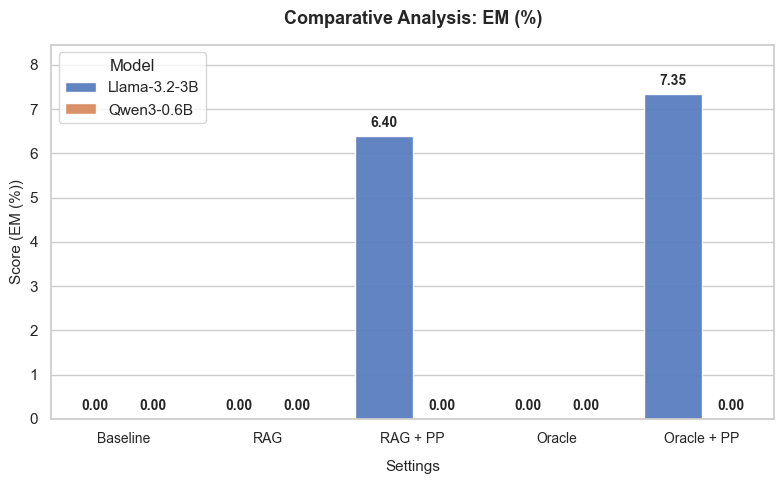

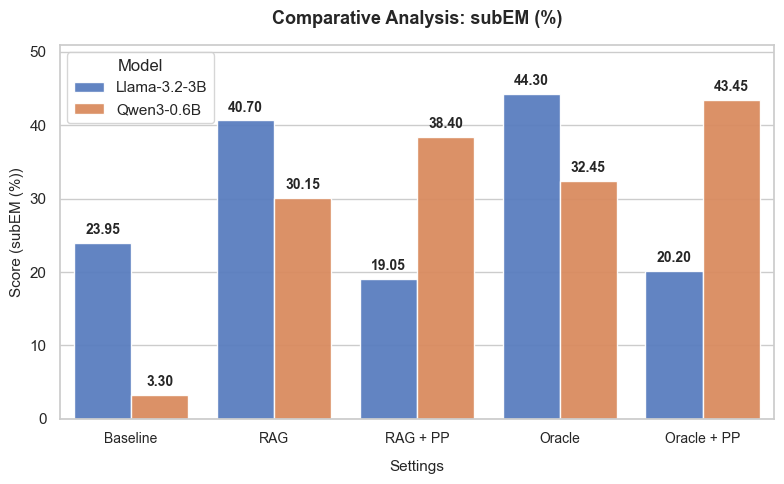

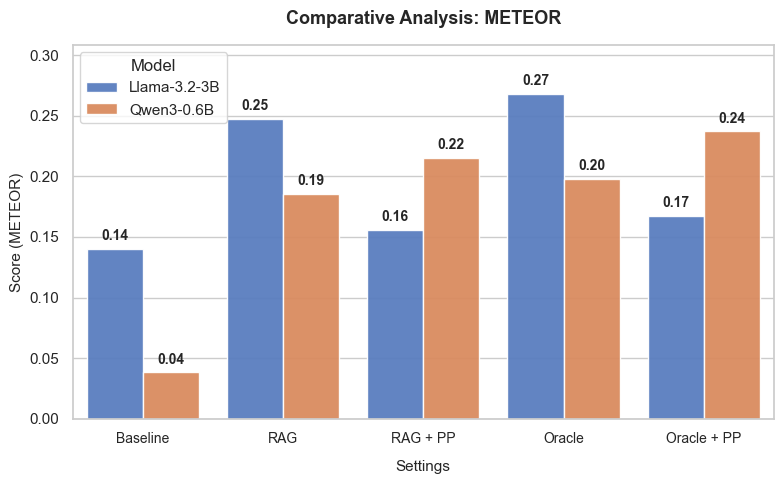

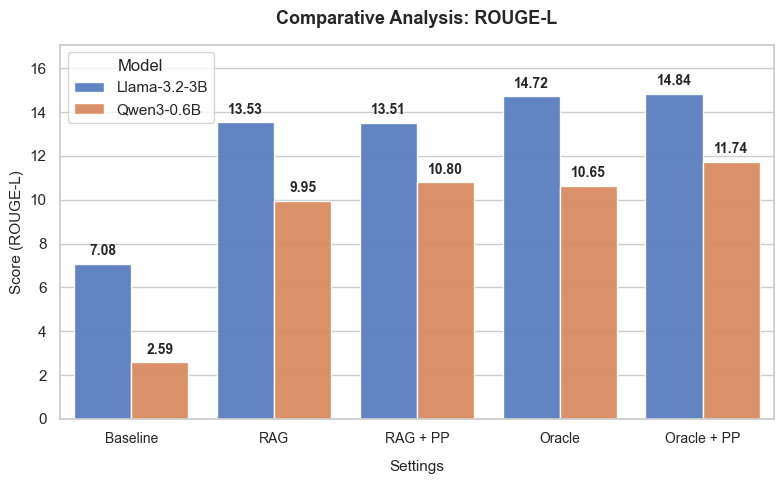

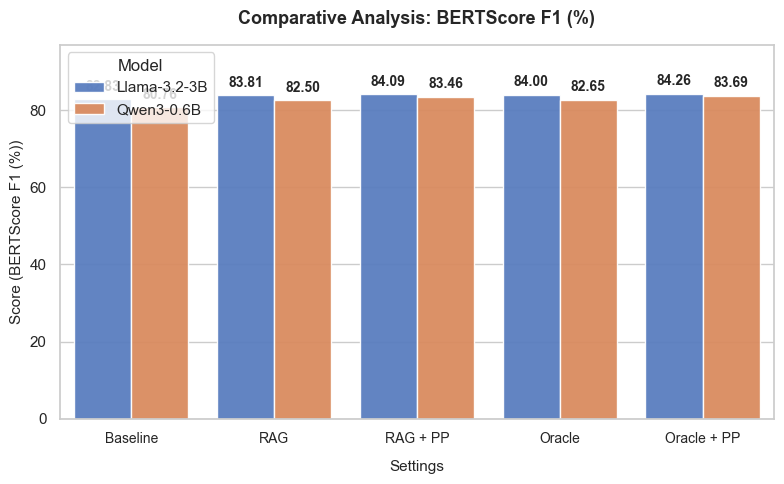

In [37]:
sns.set_theme(style="whitegrid")

metrics = ["EM (%)", "subEM (%)", "METEOR", "ROUGE-L", "BERTScore F1 (%)"]

setup_order = [
    "Baseline",
    "RAG",
    "RAG + PP",
    "Oracle",
    "Oracle + PP"
]

for metric in metrics:


    fig, ax = plt.subplots(figsize=(8, 5))

    sns.barplot(
        data=df_results,
        x="Setup",
        y=metric,
        hue="Model",
        order=setup_order,
        palette="muted",
        alpha=0.95,
        ax=ax
    )


    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=4, fontsize=10, weight='bold')

    ax.set_title(f"Comparative Analysis: {metric}", fontsize=13, weight='bold', pad=15)
    ax.set_xlabel("Settings", fontsize=11, labelpad=10)
    ax.set_ylabel(f"Score ({metric})", fontsize=11)


    ax.tick_params(axis='x', labelsize=10)


    max_value = df_results[metric].max()
    ax.set_ylim(0, max_value * 1.15 if max_value > 0 else 100.0)

    ax.legend(title="Model", loc="upper left", frameon=True)

    plt.tight_layout()

    file_name = f"plot_{metric.replace(' (%)', '').replace('-', '_')}.png"
    save_path = os.path.join(PLOTS_DIR, file_name)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()

## **LLM as a Judge**

### **Model Initialization**

In [ ]:
test_limited = test.select(range(250))

llama_answers = dict(list(Llama_RAG_test_answers.items())[:250])
qwen_answers = dict(list(Qwen_RAG_test_answers.items())[:250])

api_key = input("Please enter your Google Generative AI API Key: ")
genai.configure(api_key=api_key)
gemini_25_flash = genai.GenerativeModel("models/gemini-3.1-flash-lite")

### **Judge Functions**

In [ ]:
def judge_correctness(query: str, generated_answer: str, short_answer: str, model) -> dict:

    prompt = f"""You are an impartial judge of my RAG system. Evaluate whether the answer is correct.

Query: {query}
Generated Answer: {generated_answer}
Short Answer: {short_answer}

1 → if the correct (short) answer is present in any valid form (e.g., “twenty-four”
instead of “24”, or “Rome was founded in 753 BCE” instead of “753 BCE”)
0 → if the correct (short) answer is not present in any valid form (e.g, “It was
located in Rome”, instead of the correct answer “Milan”)
Respond only with valid JSON: {{"score": <int>, "reasoning": "<string>"}}"""

    response = model.generate_content(
        prompt,
        generation_config=genai.GenerationConfig(response_mime_type="application/json")
    )

    return json.loads(response.text)

def llm_as_a_judge(predictions_dict, dataset, model):

    ground_truths = {item['query_id']: item['short_answer'] for item in dataset}
    queries = {item['query_id']: item['query'] for item in dataset}

    answers = {}
    results = []

    for i, (q_id, pred) in enumerate(predictions_dict.items()):

        s_answer = ground_truths.get(q_id, "")

        query = queries.get(q_id, "")
        gen_answer = pred.get("generated_answer", "")

        try:
            result = judge_correctness(query, gen_answer, s_answer, model)
            results.append({"query_id": q_id, **result})
            print(f"Judged sample {i+1}/{len(predictions_dict)}")
            # Rate limiting: max 15 RPM → wait 4 seconds between requests
            time.sleep(4)

        except Exception as e:
            print(f"Error sample {q_id}: {e}")
            time.sleep(60)  # backoff in case of errors
            result = {"score": 0, "reasoning": "API Error or Timeout"}

        answers[q_id] = {
            "query_id": q_id,
            "retrieved_chunks": pred.get("retrieved_chunks"),
            "augmented_prompt": pred.get("augmented_prompt"),
            "generated_answer": gen_answer,
            "short_answer": s_answer,
            "LLM Judge Score": result.get("score"),
            "LLM Judge Reasoning": result.get("reasoning")
        }

    print(f"Completed {len(results)} evaluations.")

    return answers

### **Judge Evaluation**

In [ ]:
gemini_llama_evaluations = llm_as_a_judge(llama_answers, test_limited, gemini_25_flash)
save_jsonl(gemini_llama_evaluations, "hit_k_1_-limited-test-Llama-3.2-3B-RAG-gemini2.5-flash-evaluation.jsonl", NO_REQUESTED_OUTPUTS_DIR)
gemini_llama_evaluations = load_jsonl("hit_k_1_-limited-test-Llama-3.2-3B-RAG-gemini2.5-flash-evaluation.jsonl", NO_REQUESTED_OUTPUTS_DIR)

list_llama = list(gemini_llama_evaluations.values())
df = pd.DataFrame(list_llama)
df.to_csv(os.path.join(NO_REQUESTED_OUTPUTS_DIR, "gemini_llama_evaluations.csv"), index=False, encoding='utf-8')


gemini_qwen_evaluations = llm_as_a_judge(qwen_answers, test_limited, gemini_25_flash)
save_jsonl(gemini_qwen_evaluations, "hit_k_1_-limited-test-Qwen3-0.6B-RAG-gemini2.5-flash-evaluation.jsonl", NO_REQUESTED_OUTPUTS_DIR)

list_qwen = list(gemini_qwen_evaluations.values())
df = pd.DataFrame(list_qwen)
df.to_csv(os.path.join(NO_REQUESTED_OUTPUTS_DIR, "gemini_qwen_evaluations.csv"), index=False, encoding='utf-8')

✅ File loaded successfully: C:/Users/djmat/Desktop/Magistrale - Engineering in CS and AI - Sapienza/Multilingual_Natural_Language_Processing/MNLP_Project_2026\no_requested_outputs\hit_k_1_-limited-test-Llama-3.2-3B-RAG-gemini2.5-flash-evaluation.jsonl (250 query)


## **Manual Validation and LLM Judge Agreement**

### **Labels Loading**

In [ ]:
df_llama = pd.read_csv(os.path.join(NO_REQUESTED_OUTPUTS_DIR if not kaggle else JSON_DIR, "gemini_llama_evaluations.csv"))
df_qwen = pd.read_csv(os.path.join(NO_REQUESTED_OUTPUTS_DIR if not kaggle else JSON_DIR, "gemini_qwen_evaluations.csv"))

In [ ]:
# Accuracy Calculation

acc_mattia_llama = df_llama['Annotator 1 (Mattia)'].mean() * 100
acc_nicolo_llama = df_llama['Annotator 2 (Nicolo)'].mean() * 100
acc_gemini_llama = df_llama['LLM Judge Score'].mean() * 100

acc_mattia_qwen = df_qwen['Annotator 1 (Mattia)'].mean() * 100
acc_nicolo_qwen = df_qwen['Annotator 2 (Nicolo)'].mean() * 100
acc_gemini_qwen = df_qwen['LLM Judge Score'].mean() * 100

df_accuracy = pd.DataFrame({
    "Judge": [
        "Mattia",
        "Nicolò",
        "Gemini (LLM)"
    ],
    "Accuracy Llama (%)": [acc_mattia_llama, acc_nicolo_llama, acc_gemini_llama],
    "Accuracy Qwen (%)": [acc_mattia_qwen, acc_nicolo_qwen, acc_gemini_qwen]
}).round(1)

print("--- ACCURACY (Performance) ---")
display(df_accuracy)


# Kappa Coefficient Calculation t

kappa_mattia_nicolo_llama = cohen_kappa_score(df_llama['Annotator 1 (Mattia)'].to_numpy(), df_llama['Annotator 2 (Nicolo)'].to_numpy())
kappa_mattia_gemini_llama = cohen_kappa_score(df_llama['Annotator 1 (Mattia)'].to_numpy(), df_llama['LLM Judge Score'].to_numpy())
kappa_nicolo_gemini_llama = cohen_kappa_score(df_llama['Annotator 2 (Nicolo)'].to_numpy(), df_llama['LLM Judge Score'].to_numpy())

kappa_mattia_nicolo_qwen = cohen_kappa_score(df_qwen['Annotator 1 (Mattia)'].to_numpy(), df_qwen['Annotator 2 (Nicolo)'].to_numpy())
kappa_mattia_gemini_qwen = cohen_kappa_score(df_qwen['Annotator 1 (Mattia)'].to_numpy(), df_qwen['LLM Judge Score'].to_numpy())
kappa_nicolo_gemini_qwen = cohen_kappa_score(df_qwen['Annotator 2 (Nicolo)'].to_numpy(), df_qwen['LLM Judge Score'].to_numpy())

df_kappa = pd.DataFrame({
    "Judges couples": [
        "Mattia vs Nicolò (Umani)",
        "Mattia vs Gemini (Umano-LLM)",
        "Nicolò vs Gemini (Umano-LLM)"
    ],
    "Kappa Llama": [kappa_mattia_nicolo_llama, kappa_mattia_gemini_llama, kappa_nicolo_gemini_llama],
    "Kappa Qwen": [kappa_mattia_nicolo_qwen, kappa_mattia_gemini_qwen, kappa_nicolo_gemini_qwen]
}).round(3)

print("\n--- AGREEMENT (Cohen's Kappa) ---")
display(df_kappa)

--- ACCURACY (Performance) ---


,Judge,Accuracy Llama (%),Accuracy Qwen (%)
0,Mattia,60.4,44.0
1,Nicolò,57.2,44.4
2,Gemini (LLM),64.4,58.8



--- AGREEMENT (Cohen's Kappa) ---


,Judges couples,Kappa Llama,Kappa Qwen
0,Mattia vs Nicolò (Umani),0.852,0.911
1,Mattia vs Gemini (Umano-LLM),0.694,0.459
2,Nicolò vs Gemini (Umano-LLM),0.616,0.467


### **Plot Area**

Accuracy plot saved to: C:/Users/djmat/Desktop/Magistrale - Engineering in CS and AI - Sapienza/Multilingual_Natural_Language_Processing/MNLP_Project_2026\plots\plot_human_eval_accuracy.png


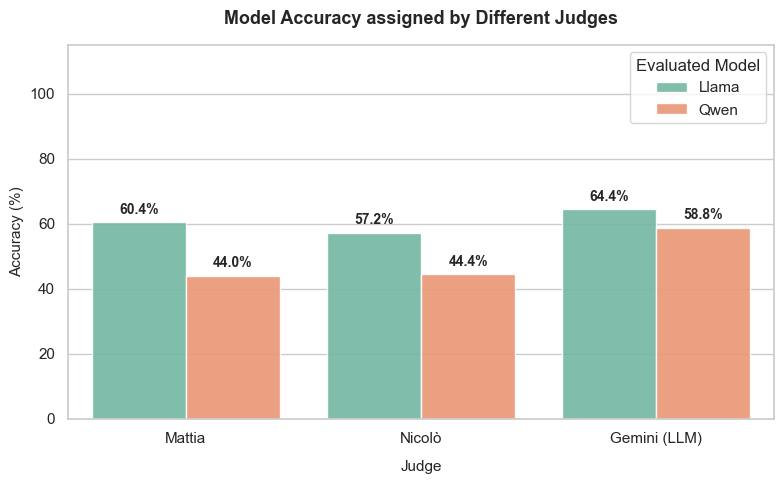

Kappa plot saved to: C:/Users/djmat/Desktop/Magistrale - Engineering in CS and AI - Sapienza/Multilingual_Natural_Language_Processing/MNLP_Project_2026\plots\plot_human_eval_kappa.png


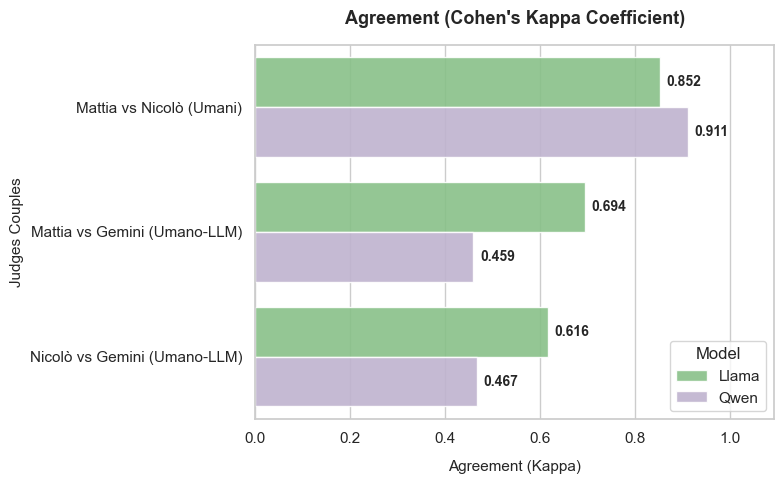

In [ ]:
sns.set_theme(style="whitegrid")

df_acc_long = pd.melt(
    df_accuracy,
    id_vars=["Judge"],
    value_vars=["Accuracy Llama (%)", "Accuracy Qwen (%)"],
    var_name="Model",
    value_name="Accuracy"
)

df_acc_long["Model"] = df_acc_long["Model"].str.replace("Accuracy ", "").str.replace(" (%)", "")

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=df_acc_long,
    x="Judge",
    y="Accuracy",
    hue="Model",
    palette="Set2",
    alpha=0.9,
    ax=ax
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=4, fontsize=10, weight='bold')

ax.set_title("Model Accuracy assigned by Different Judges", fontsize=13, weight='bold', pad=15)
ax.set_xlabel("Judge", fontsize=11, labelpad=10)
ax.set_ylabel("Accuracy (%)", fontsize=11)
ax.set_ylim(0, 115)
ax.legend(title="Evaluated Model", loc="upper right")

plt.tight_layout()

path_acc = os.path.join(PLOTS_DIR, "plot_human_eval_accuracy.png")
plt.savefig(path_acc, dpi=300, bbox_inches='tight')
print(f"Accuracy plot saved to: {path_acc}")
plt.show()

df_kappa_long = pd.melt(
    df_kappa,
    id_vars=["Judges couples"],
    value_vars=["Kappa Llama", "Kappa Qwen"],
    var_name="Model",
    value_name="Kappa"
)
df_kappa_long["Model"] = df_kappa_long["Model"].str.replace("Kappa ", "")

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=df_kappa_long,
    y="Judges couples",
    x="Kappa",
    hue="Model",
    palette="Accent",
    alpha=0.9,
    ax=ax
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=5, fontsize=10, weight='bold')

ax.set_title("Agreement (Cohen's Kappa Coefficient)", fontsize=13, weight='bold', pad=15)
ax.set_xlabel("Agreement (Kappa)", fontsize=11, labelpad=10)
ax.set_ylabel("Judges Couples", fontsize=11)

max_kappa = df_kappa_long["Kappa"].max()
ax.set_xlim(0, max_kappa * 1.2 if max_kappa > 0 else 1.0)

ax.legend(title="Model", loc="lower right")

plt.tight_layout()
path_kappa = os.path.join(PLOTS_DIR, "plot_human_eval_kappa.png")
plt.savefig(path_kappa, dpi=300, bbox_inches='tight')
print(f"Kappa plot saved to: {path_kappa}")
plt.show()

## **Faithfulness Detection**

### **Model Initialization**

In [ ]:
test_limited = test.select(range(250))

llama_answers = dict(list(Llama_RAG_test_answers.items())[:250])
qwen_answers = dict(list(Qwen_RAG_test_answers.items())[:250])

api_key = input("Please enter your Google Generative AI API Key: ")
genai.configure(api_key=api_key)
gemini_25_flash = genai.GenerativeModel("models/gemini-3.1-flash-lite")

### **Judge Functions**


In [ ]:
def judge_faithfulness(generated_answer: str, retrieved_chunks: str, model) -> dict:

    prompt = f"""You are a strict Faithfulness Judge for a RAG (Retrieval-Augmented Generation) system.

Your ONLY job is to decide whether every claim in the Generated Answer can be directly inferred from the Retrieved Context.
You must IGNORE your own world knowledge: even a factually correct statement counts as UNFAITHFUL if it is not supported by the context.

---
RETRIEVED CONTEXT:
{retrieved_chunks}

---
GENERATED ANSWER:
{generated_answer}

---
SCORING SCALE:
5 → Every single claim in the answer is explicitly or clearly implicitly supported by the context.
4 → Nearly all claims are grounded; at most one minor unsupported detail present.
3 → Most claims are grounded, but there are noticeable gaps or mild extrapolations beyond the context.
2 → Several claims go beyond or contradict the context; hallucinated and grounded content are mixed significantly.
1 → The answer mostly or entirely ignores or contradicts the context (total hallucination).

---
INSTRUCTIONS — follow this exact chain-of-thought order before scoring:

Step 1 – List the key factual claims made in the Generated Answer (bullet points).
Step 2 – For each claim, state whether it is SUPPORTED, PARTIALLY SUPPORTED, or UNSUPPORTED by the Retrieved Context, and quote or cite the relevant part of the context (or note its absence).
Step 3 – Weigh the overall proportion of unsupported or contradicted claims.
Step 4 – Assign a score from 1 to 5 based on the scale above.

Output ONLY valid JSON with this exact structure (reasoning MUST come before score):
{{
  "reasoning": "<your full chain-of-thought from Steps 1-3>",
  "score": <integer 1-5>
}}"""

    response = model.generate_content(
        prompt,
        generation_config=genai.GenerationConfig(response_mime_type="application/json")
    )
    return json.loads(response.text)


def llm_judge_faithfulness(predictions_dict: dict, dataset, model) -> dict:
    # Build a lookup: query_id → candidate_chunks
    chunks_lookup = dict(zip(dataset['query_id'], dataset['candidate_chunks']))

    answers = {}
    n = len(predictions_dict)

    for i, (q_id, pred) in enumerate(predictions_dict.items(), start=1):

        gen_answer = pred.get("generated_answer", "")
        chunk_indices = pred.get("retrieved_chunks", [])

        # Resolve indices → actual text
        candidates = chunks_lookup.get(q_id, [])
        chunks_text = "\n\n".join(candidates[idx] for idx in chunk_indices)

        try:
            result = judge_faithfulness(gen_answer, chunks_text, model)
            print(f"Judged sample {i}/{n} — score: {result.get('score')}")
            time.sleep(4)
        except Exception as e:
            print(f"Error sample {q_id}: {e}")
            time.sleep(60)
            result = {"score": 0, "reasoning": "API Error or Timeout"}

        answers[q_id] = {
            "query_id": q_id,
            "retrieved_chunks": chunk_indices,
            "generated_answer": gen_answer,
            "Faithfulness Score": result.get("score"),
            "Faithfulness Reasoning": result.get("reasoning"),
        }

    return answers

### **Judge Evaluation**

In [ ]:
gemini_llama_faithfulness = llm_judge_faithfulness(llama_answers, test_limited, gemini_25_flash)
save_jsonl(gemini_llama_faithfulness, "llama_faithfulness.jsonl", NO_REQUESTED_OUTPUTS_DIR)
gemini_llama_faithfulness = load_jsonl("llama_faithfulness.jsonl", NO_REQUESTED_OUTPUTS_DIR)

df_llama_faith = pd.DataFrame(list(gemini_llama_faithfulness.values()))
df_llama_faith.to_csv(os.path.join(NO_REQUESTED_OUTPUTS_DIR, "llama_faithfulness.csv"), index=False, encoding='utf-8')

gemini_qwen_faithfulness = llm_judge_faithfulness(qwen_answers,  test_limited, gemini_25_flash)
save_jsonl(gemini_qwen_faithfulness, "qwen_faithfulness.jsonl",  NO_REQUESTED_OUTPUTS_DIR)
gemini_qwen_faithfulness = load_jsonl("qwen_faithfulness.jsonl",  NO_REQUESTED_OUTPUTS_DIR)

df_qwen_faith = pd.DataFrame(list(gemini_qwen_faithfulness.values()))
df_qwen_faith.to_csv(os.path.join(NO_REQUESTED_OUTPUTS_DIR, "qwen_faithfulness.csv"),  index=False, encoding='utf-8')

### **Statistics**

In [ ]:
df_llama_faith = pd.read_csv(os.path.join(NO_REQUESTED_OUTPUTS_DIR if not kaggle else JSON_DIR, "llama_faithfulness.csv"))
df_qwen_faith = pd.read_csv(os.path.join(NO_REQUESTED_OUTPUTS_DIR if not kaggle else JSON_DIR, "qwen_faithfulness.csv"))

In [ ]:
df_faith_summary = pd.DataFrame({
    "Model": ["Llama-3.2-3B", "Qwen3-0.6B"],
    "Mean Faithfulness Score": [
        df_llama_faith["Faithfulness Score"].mean(),
        df_qwen_faith["Faithfulness Score"].mean()
    ],
    "Standard Deviation": [
        df_llama_faith["Faithfulness Score"].std(),
        df_qwen_faith["Faithfulness Score"].std()
    ],
    "% Score 5 (Perfectly Faithful)": [
        (df_llama_faith["Faithfulness Score"] == 5).mean() * 100,
        (df_qwen_faith["Faithfulness Score"]  == 5).mean() * 100
    ],
    "% Score 1 (Total Hallucination)": [
        (df_llama_faith["Faithfulness Score"] == 1).mean() * 100,
        (df_qwen_faith["Faithfulness Score"]  == 1).mean() * 100
    ],
}).round(2)

print("--- FAITHFULNESS SUMMARY ---")
display(df_faith_summary)

### **Plot Area**

In [ ]:
sns.set_theme(style="whitegrid")

# Plot Mean Faithfulness Score
fig, ax = plt.subplots(figsize=(7, 5))

sns.barplot(
    data=df_faith_summary,
    x="Model",
    y="Mean Faithfulness Score",
    palette="Set2",
    alpha=0.9,
    ax=ax
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=4, fontsize=11, weight='bold')

ax.set_title("Mean Faithfulness Score by Model (1–5)", fontsize=13, weight='bold', pad=15)
ax.set_xlabel("Model", fontsize=11, labelpad=10)
ax.set_ylabel("Mean Score", fontsize=11)
ax.set_ylim(0, 5.5)

plt.tight_layout()
path = os.path.join(PLOTS_DIR, "plot_faithfulness_mean.png")
plt.savefig(path, dpi=300, bbox_inches='tight')
print(f"Plot saved to: {path}")
plt.show()


# Plot Score Distribution (1–5) per model
df_llama_faith["Model"] = "Llama-3.2-3B"
df_qwen_faith["Model"]  = "Qwen3-0.6B"
df_combined = pd.concat([df_llama_faith, df_qwen_faith], ignore_index=True)

fig, ax = plt.subplots(figsize=(9, 5))

sns.countplot(
    data=df_combined,
    x="Faithfulness Score",
    hue="Model",
    palette="Set2",
    alpha=0.9,
    ax=ax
)

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10, weight='bold')

ax.set_title("Faithfulness Score Distribution by Model", fontsize=13, weight='bold', pad=15)
ax.set_xlabel("Faithfulness Score (1 = Hallucination, 5 = Perfectly Faithful)", fontsize=11, labelpad=10)
ax.set_ylabel("Number of Samples", fontsize=11)
ax.legend(title="Model", loc="upper left")

plt.tight_layout()
path = os.path.join(PLOTS_DIR, "plot_faithfulness_distribution.png")
plt.savefig(path, dpi=300, bbox_inches='tight')
print(f"Plot saved to: {path}")
plt.show()